In [5]:
"""
ZTF AGN Lightcurve Pipeline
============================
1. Query SDSS QSO catalog via CasJobs SQL (TOP 1000, deduplicated on bestobjid)
2. For each QSO, fetch g+r lightcurves from IRSA ZTF LC-API (3" cone search)
3. Keep best positional match (closest ZTF oid) per source
4. Filter bad epochs (catflags != 0)
5. Store as HDF5 via pandas HDFStore:
       /ztf_agn_lc/<bestobjid>  →  DataFrame columns: time_g, mag_g, magerr_g,
                                                      time_r, mag_r, magerr_r,
                                                      g_oid, r_oid
   g and r are time-union indexed; NaN where bands don't overlap.

Dependencies:
    pip install astroquery pandas requests numpy
"""

import warnings
from tables import NaturalNameWarning
warnings.filterwarnings("ignore", category=NaturalNameWarning)

import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from astroquery.sdss import SDSS
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import ascii as astropy_ascii

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

OUTPUT_HDF5 = Path("ztf_agn_lc.h5")
HDF5_ROOT   = "ztf_agn_lc"         # top-level HDF5 group

ZTF_LC_API  = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"
SEARCH_RADIUS_DEG = 3.0 / 3600.0   # 3 arcsec in degrees
BAD_CATFLAGS_MASK = 32768           # standard ZTF bad-epoch bitmask
REQUEST_DELAY_SEC = 0.5             # polite delay between IRSA requests
TOT_NUM_SDSS_OBJ = 10

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# ---------------------------------------------------------------------------
# Step 1 — Query SDSS QSO catalog
# ---------------------------------------------------------------------------

SDSS_SQL = f"""
SELECT TOP {TOT_NUM_SDSS_OBJ}
    s.bestobjid,
    s.ra,
    s.dec,
    s.z        AS redshift,
    s.class,
    s.subclass
FROM SpecObj AS s
WHERE
    s.class    = 'QSO'
    AND s.bestobjid IS NOT NULL
    AND s.bestobjid > 0
GROUP BY
    s.bestobjid, s.ra, s.dec, s.z, s.class, s.subclass
ORDER BY
    s.bestobjid
"""
# GROUP BY bestobjid ensures deduplication: if multiple spectra share the
# same bestobjid (re-observations), only one row survives.


def query_sdss_qsos() -> pd.DataFrame:
    """Run SDSS SQL via astroquery and return a clean DataFrame."""
    log.info("Querying SDSS CasJobs …")
    result = SDSS.query_sql(SDSS_SQL)
    if result is None or len(result) == 0:
        raise RuntimeError("SDSS query returned no results.")
    df = result.to_pandas()
    log.info("SDSS: %d QSOs returned", len(df))

    # Defensive deduplication in pandas (in case SQL GROUP BY left any edge cases)
    before = len(df)
    df = df.drop_duplicates(subset="bestobjid").reset_index(drop=True)
    if len(df) < before:
        log.warning("Dropped %d duplicate bestobjid rows post-SQL", before - len(df))

    return df


# ---------------------------------------------------------------------------
# Step 2 — Fetch ZTF lightcurves from IRSA LC-API
# ---------------------------------------------------------------------------

def fetch_ztf_lc(ra: float, dec: float) -> pd.DataFrame | None:
    params = {
        "POS":               f"CIRCLE {ra} {dec} {SEARCH_RADIUS_DEG}",
        "BANDNAME":          "g,r",
        "BAD_CATFLAGS_MASK": BAD_CATFLAGS_MASK,
        "FORMAT":            "ipac_table",
    }
    try:
        resp = requests.get(ZTF_LC_API, params=params, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as exc:
        log.warning("IRSA request failed for RA=%.5f Dec=%.5f: %s", ra, dec, exc)
        return None

    if not resp.text.strip() or "oid" not in resp.text:
        return None  # empty response

    try:
        table = astropy_ascii.read(resp.text, format="ipac")
    except Exception as exc:
        log.warning("Failed to parse IPAC table for RA=%.5f Dec=%.5f: %s", ra, dec, exc)
        return None

    if len(table) == 0:
        return None

    df = table.to_pandas()

    for col in ["ra", "dec", "hjd", "mag", "magerr", "catflags", "oid"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


# ---------------------------------------------------------------------------
# Step 3 — Select best ZTF match (closest oid per band) and build per-band DataFrames
# ---------------------------------------------------------------------------

def select_best_oid_per_band(
    lc_df: pd.DataFrame, ra: float, dec: float
) -> dict[str, int | None]:
    """
    For each band (zg, zr), pick the oid whose median position is closest
    to the SDSS QSO coordinates. Returns {"zg": oid_or_None, "zr": oid_or_None}.
    """
    source_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    result = {"zg": None, "zr": None}

    for band in ("zg", "zr"):
        band_df = lc_df[lc_df["filtercode"] == band]
        best_oid, best_sep = None, np.inf
        for oid, grp in band_df.groupby("oid"):
            ztf_coord = SkyCoord(
                ra=grp["ra"].median() * u.deg,
                dec=grp["dec"].median() * u.deg,
            )
            sep = source_coord.separation(ztf_coord).arcsec
            if sep < best_sep:
                best_sep = sep
                best_oid = oid
        result[band] = best_oid

    return result


def build_merged_lightcurve(
    lc_df: pd.DataFrame, oids: dict[str, int | None]
) -> pd.DataFrame | None:
    """
    Build a time-union DataFrame from the best g-band oid and best r-band oid.
    Includes persistent g_oid and r_oid tracking columns.
    """
    frames = []

    oid_g = oids["zg"]
    oid_r = oids["zr"]

    if oid_g is not None:
        g = lc_df[lc_df["oid"] == oid_g][["hjd", "mag", "magerr"]].copy()
        g = g.rename(columns={"hjd": "time_g", "mag": "mag_g", "magerr": "magerr_g"})
        frames.append(g.reset_index(drop=True))

    if oid_r is not None:
        r = lc_df[lc_df["oid"] == oid_r][["hjd", "mag", "magerr"]].copy()
        r = r.rename(columns={"hjd": "time_r", "mag": "mag_r", "magerr": "magerr_r"})
        frames.append(r.reset_index(drop=True))

    if not frames:
        return None

    merged = pd.concat(frames, axis=0, ignore_index=True)
    merged["_t"] = merged["time_g"].fillna(merged["time_r"])
    merged = merged.sort_values("_t").drop(columns="_t").reset_index(drop=True)

    merged["g_oid"] = oid_g
    merged["r_oid"] = oid_r

    return merged


# ---------------------------------------------------------------------------
# Step 4 — Write to HDF5 via pandas HDFStore
# ---------------------------------------------------------------------------

def save_to_hdf5(bestobjid: int, lc: pd.DataFrame, store: pd.HDFStore) -> None:
    """Write a single object's lightcurve DataFrame into the HDFStore using its SDSS ID."""
    key = f"/{HDF5_ROOT}/{bestobjid}"
    store.put(key, lc, format="fixed", data_columns=True)


# ---------------------------------------------------------------------------
# Main pipeline
# ---------------------------------------------------------------------------

def main() -> None:
    # --- SDSS ---
    sdss_df = query_sdss_qsos()

    n_total    = len(sdss_df)
    n_matched  = 0
    n_no_match = 0
    n_error    = 0

    with pd.HDFStore(OUTPUT_HDF5, mode="w", complevel=5, complib="blosc") as store:
        for idx, row in sdss_df.iterrows():
            ra, dec = float(row["ra"]), float(row["dec"])
            bestobjid = row["bestobjid"]

            log.info(
                "[%4d/%d] bestobjid=%s  RA=%.5f  Dec=%.5f",
                idx + 1, n_total, bestobjid, ra, dec,
            )

            # --- ZTF cone search ---
            lc_df = fetch_ztf_lc(ra, dec)
            time.sleep(REQUEST_DELAY_SEC)

            if lc_df is None or lc_df.empty:
                log.debug("  → no ZTF detections within cone")
                n_no_match += 1
                continue

            # --- Best positional match per band ---
            oids = select_best_oid_per_band(lc_df, ra, dec)
            if oids["zg"] is None and oids["zr"] is None:
                n_no_match += 1
                continue

            # --- Build merged g+r lightcurve ---
            lc = build_merged_lightcurve(lc_df, oids)
            if lc is None or lc.empty:
                n_error += 1
                continue

            # --- Write to HDF5 (keyed by SDSS bestobjid) ---
            key = f"/{HDF5_ROOT}/{bestobjid}"
            if key in store:
                log.warning(
                    "  → bestobjid=%s already in store (duplicate SDSS object); skipping",
                    bestobjid,
                )
                n_error += 1
                continue

            save_to_hdf5(bestobjid, lc, store)
            n_matched += 1

            log.info(
                "  → oid_g=%s  oid_r=%s  g_epochs=%d  r_epochs=%d  saved",
                oids["zg"], oids["zr"],
                lc["mag_g"].notna().sum(),
                lc["mag_r"].notna().sum(),
            )

    # --- Summary ---
    log.info("=" * 60)
    log.info("Pipeline complete.")
    log.info("  SDSS QSOs queried : %d", n_total)
    log.info("  ZTF matches saved : %d  →  %s", n_matched, OUTPUT_HDF5)
    log.info("  No ZTF match      : %d", n_no_match)
    log.info("  Skipped (other)   : %d", n_error)
    log.info("=" * 60)


if __name__ == "__main__":
    main()

16:48:13  INFO      Querying SDSS CasJobs …
16:48:13  INFO      SDSS: 10 QSOs returned
16:48:13  INFO      [   1/10] bestobjid=1197126704423239975  RA=238.23135  Dec=55.93361
16:48:43  WARNING   IRSA request failed for RA=238.23135 Dec=55.93361: HTTPSConnectionPool(host='irsa.ipac.caltech.edu', port=443): Read timed out. (read timeout=30)
16:48:44  INFO      [   2/10] bestobjid=1197126704428810393  RA=238.55945  Dec=43.16305
16:49:14  WARNING   IRSA request failed for RA=238.55945 Dec=43.16305: HTTPSConnectionPool(host='irsa.ipac.caltech.edu', port=443): Read timed out. (read timeout=30)
16:49:15  INFO      [   3/10] bestobjid=1197126704428875838  RA=238.43512  Dec=43.10423
16:49:45  WARNING   IRSA request failed for RA=238.43512 Dec=43.10423: HTTPSConnectionPool(host='irsa.ipac.caltech.edu', port=443): Read timed out. (read timeout=30)
16:49:46  INFO      [   4/10] bestobjid=1197126704428875872  RA=238.49717  Dec=43.15542
16:50:02  INFO        → oid_g=721113300001248  oid_r=7212133000

Parsing HDF5 Catalog details...

--- Complete Catalog Summary Table ---
             bestobjid  g_epochs  r_epochs
0  1197126704428875872      1242      1309
1  1197126705520378125       354        15
2  1197126709252456640       576      1165
3  1197128457305653413       621       681
4  1197128466986893403        22       626
5  1197128707508338876        24        37
6  1197131404758811462       649        83

--- Filtered Objects (Min 5 epochs in both bands) ---
             bestobjid  g_epochs  r_epochs
0  1197126704428875872      1242      1309

Plotting and extracting target: 1197126704428875872...


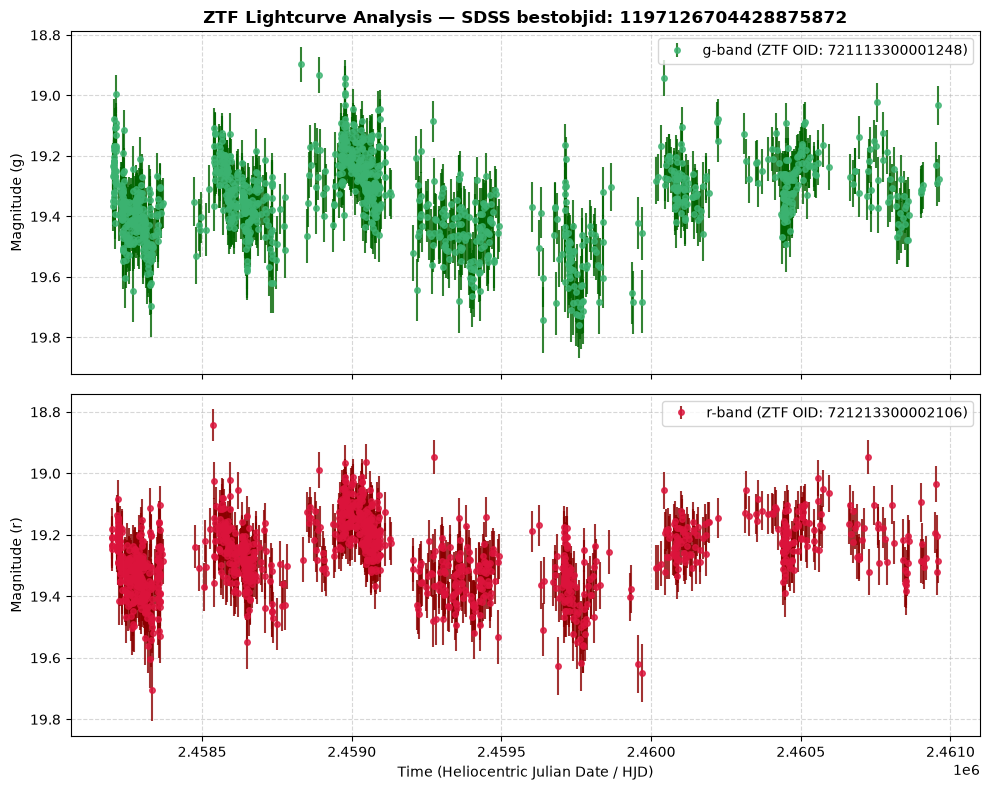


Extraction metrics verification:
  g-band time vector type: <class 'numpy.ndarray'> | Shape: (1242,)
  r-band time vector type: <class 'numpy.ndarray'> | Shape: (1309,)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HDF5_FILE = "ztf_agn_lc.h5"
HDF5_ROOT = "ztf_agn_lc"

# ===========================================================================
# 1. Compute Epoch Statistics Across the Whole Catalog
# ===========================================================================

def calculate_catalog_epochs(file_path: str) -> pd.DataFrame:
    """
    Opens the HDF5 store, loops through all available objects, and counts
    the total number of real, non-NaN observations (epochs) for g and r bands.
    """
    summary_data = []
    
    with pd.HDFStore(file_path, mode="r") as store:
        for key in store.keys():
            # Keys look like '/ztf_agn_lc/1234567'. Extract the actual bestobjid.
            bestobjid = key.split("/")[-1]
            df = store[key]
            
            # Count elements that are not missing (NaN)
            g_epochs = df["mag_g"].notna().sum()
            r_epochs = df["mag_r"].notna().sum()
            
            summary_data.append({
                "bestobjid": int(bestobjid),
                "g_epochs": int(g_epochs),
                "r_epochs": int(r_epochs)
            })
            
    return pd.DataFrame(summary_data)


# ===========================================================================
# 2. Filter Catalog by Minimal and Maximal Epoch Thresholds
# ===========================================================================

def filter_by_epochs(
    summary_df: pd.DataFrame, 
    min_g: int = 0, 
    max_g: int = None, 
    min_r: int = 0, 
    max_r: int = None
) -> pd.DataFrame:
    """
    Filters the summary catalog DataFrame using minimum and maximum bounds 
    for both the g-band and r-band epoch counts.
    """
    # Initialize mask for minimum conditions
    mask = (summary_df["g_epochs"] >= min_g) & (summary_df["r_epochs"] >= min_r)
    
    # Apply maximum conditions conditionally if specified
    if max_g is not None:
        mask &= (summary_df["g_epochs"] <= max_g)
    if max_r is not None:
        mask &= (summary_df["r_epochs"] <= max_r)
        
    return summary_df[mask].reset_index(drop=True)


# ===========================================================================
# 3. Plot Chosen Lightcurve and Extract Clean NumPy Arrays
# ===========================================================================

def plot_and_extract_lightcurve(file_path: str, bestobjid: int | str) -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """
    Plots the g and r band lightcurves for a chosen object in two separate subplots.
    
    Drops the interleaved NaNs to return 6 clean, unaligned NumPy arrays containing
    only the actual valid measurements for each specific band.
    """
    key = f"/{HDF5_ROOT}/{bestobjid}"
    df = pd.read_hdf(file_path, key=key)
    
    # Extract clean g-band data points (drop empty interleaved rows)
    g_data = df[["time_g", "mag_g", "magerr_g"]].dropna()
    t_g = g_data["time_g"].to_numpy()
    m_g = g_data["mag_g"].to_numpy()
    e_g = g_data["magerr_g"].to_numpy()
    
    # Extract clean r-band data points
    r_data = df[["time_r", "mag_r", "magerr_r"]].dropna()
    t_r = r_data["time_r"].to_numpy()
    m_r = r_data["mag_r"].to_numpy()
    e_r = r_data["magerr_r"].to_numpy()
    
    # Get tracking OIDs out of the DataFrame for plot labeling
    oid_g = df["g_oid"].iloc[0]
    oid_r = df["r_oid"].iloc[0]
    
    # Setup subplots sharing the timeline X-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Subplot 1: Green Band (g)
    if len(t_g) > 0:
        ax1.errorbar(t_g, m_g, yerr=e_g, fmt="o", color="mediumseagreen", 
                     ecolor="darkgreen", markersize=4, alpha=0.8, 
                     label=f"g-band (ZTF OID: {oid_g})")
        ax1.set_ylabel("Magnitude (g)")
        ax1.invert_yaxis()  # Astronomical magnitude scale is traditionally inverted
        ax1.legend(loc="upper right")
        ax1.grid(True, linestyle="--", alpha=0.5)
    else:
        ax1.text(0.5, 0.5, "No valid g-band observations", transform=ax1.transAxes, ha="center")
        
    ax1.set_title(f"ZTF Lightcurve Analysis — SDSS bestobjid: {bestobjid}", fontsize=12, fontweight="bold")

    # Subplot 2: Red Band (r)
    if len(t_r) > 0:
        ax2.errorbar(t_r, m_r, yerr=e_r, fmt="o", color="crimson", 
                     ecolor="darkred", markersize=4, alpha=0.8, 
                     label=f"r-band (ZTF OID: {oid_r})")
        ax2.set_ylabel("Magnitude (r)")
        ax2.invert_yaxis()  # Invert magnitude scale
        ax2.set_xlabel("Time (Heliocentric Julian Date / HJD)")
        ax2.legend(loc="upper right")
        ax2.grid(True, linestyle="--", alpha=0.5)
    else:
        ax2.text(0.5, 0.5, "No valid r-band observations", transform=ax2.transAxes, ha="center")
        ax2.set_xlabel("Time (Heliocentric Julian Date / HJD)")

    plt.tight_layout()
    plt.show()
    
    # Return pristine numerical data structures
    return t_g, m_g, e_g, t_r, m_r, e_r


# ===========================================================================
# Execution Example / Verification
# ===========================================================================
if __name__ == "__main__":
    # 1. Read store and show standard epoch distribution details
    print("Parsing HDF5 Catalog details...")
    summary_df = calculate_catalog_epochs(HDF5_FILE)
    print("\n--- Complete Catalog Summary Table ---")
    print(summary_df)
    
    # 2. Filter down to objects that have a strict range of observations
    # Example: grab objects with at least 5 g-band and 5 r-band epochs
    filtered_df = filter_by_epochs(summary_df, min_g=1000, min_r=1000)
    print("\n--- Filtered Objects (Min 5 epochs in both bands) ---")
    print(filtered_df)
    
    # 3. Choose one object dynamically out of the filtered set to process
    if not filtered_df.empty:
        target_id = filtered_df["bestobjid"].iloc[0]
        print(f"\nPlotting and extracting target: {target_id}...")
        
        # Execute plotting and get clean arrays back
        t_g, m_g, e_g, t_r, m_r, e_r = plot_and_extract_lightcurve(HDF5_FILE, target_id)
        
        # Verify types and lengths match actual data metrics
        print("\nExtraction metrics verification:")
        print(f"  g-band time vector type: {type(t_g)} | Shape: {t_g.shape}")
        print(f"  r-band time vector type: {type(t_r)} | Shape: {t_r.shape}")
    else:
        print("\nNo targets satisfied the filtering criteria.")